### Bibliotecas e Frameworks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist

2025-09-01 23:32:11.506336: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-01 23:32:11.550791: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-01 23:32:12.834442: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Questão 4

#### Item a)

Implemente e treine um autoencoder utilizando o dataset Fashion-MNIST, disponível em: https://www.kaggle.com/datasets/zalando-research/fashionmnist.

O  objetivo deste exercício é compreender como esse tipo de rede neural é capaz de aprender representações comprimidas de dados e realizar reconstruções a partir dessas representações.

O autoencoder pode ser construído utilizando apenas camadas densas (fully connected) ou, alternativamente, camadas convolucionais e deconvolucionais.

Após o treinamento, selecione 10 imagens do conjunto de teste e utilize o modelo treinado para gerar as reconstruções correspondentes. 

Apresente os resultados visualmente, exibindo lado a lado as imagens originais e suas respectivas reconstruções, de modo que seja possível avaliar qualitativamente o desempenho do autoencoder. Apresente também a curva do erro médio ao longo do treinamento.

In [2]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalizes Data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flattens Images for a Dense Autoencoder (2D to 1D)
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [3]:
# Dimension of the Compressed Representation
encoding_dim = 32

# Input Layer
input_ = keras.layers.Input(shape=(784,))

# Encoder
encoded = keras.layers.Dense(128, activation="relu")(input_)
encoded = keras.layers.Dense(64, activation="relu")(encoded)
encoded = keras.layers.Dense(encoding_dim, activation="relu")(
    encoded
)

# Decoder
decoded = keras.layers.Dense(64, activation="relu")(encoded)
decoded = keras.layers.Dense(128, activation="relu")(decoded)
decoded = keras.layers.Dense(784, activation="sigmoid")(decoded)

# Full Model (Autoencoder)
autoencoder = keras.Model(input_, decoded)
autoencoder.compile(optimizer="adam", loss="mean_squared_error")
autoencoder.summary()

# Train the Model
history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat),
)

W0000 00:00:1756780334.758138  134587 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0484 - val_loss: 0.0253
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0232 - val_loss: 0.0215
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0204 - val_loss: 0.0194
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0184 - val_loss: 0.0181
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0172 - val_loss: 0.0168
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0164 - val_loss: 0.0160
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0157 - val_loss: 0.0155
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0152 - val_loss: 0.0151
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0148 - val_loss: 0.0146
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0144 - val_loss: 0.0143
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ -0s -358us/step - loss: 0.0141 - val_loss: 0.0140
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/

<Figure size 640x480 with 0 Axes>

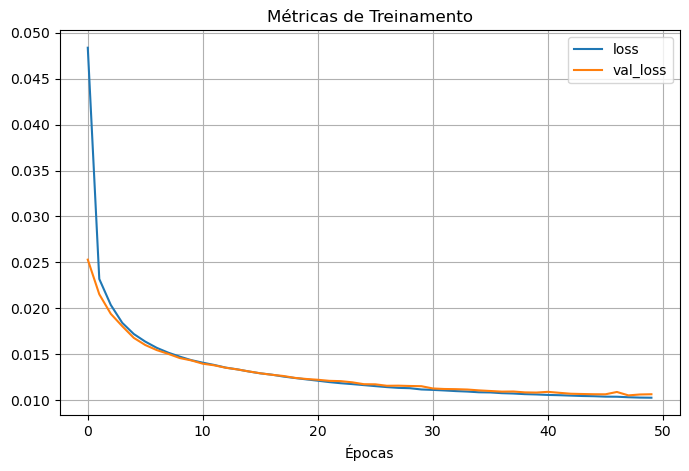

In [4]:
# Training Metrics

plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas")
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


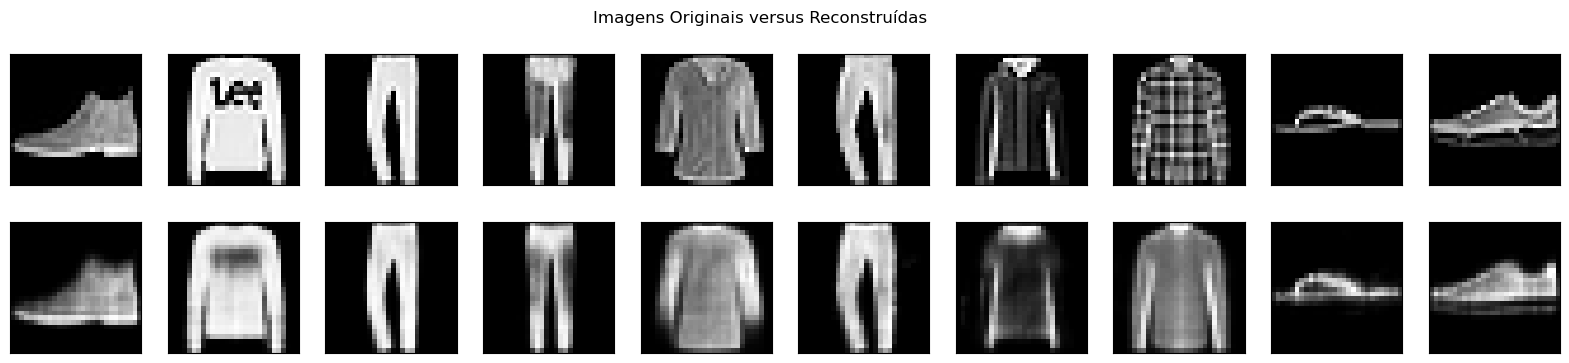

In [5]:
# Generates Reconstructions for the First 10 Images of the Test Set
reconstructed_imgs = autoencoder.predict(x_test_flat[:10])

# View Original and Reconstructed Images
n = 10  # Number of Images to Display

plt.figure(figsize=(20, 4))

for i in range(n):
    # Original Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.suptitle("Imagens Originais versus Reconstruídas")
plt.show()

#### Item b)

Complete o exercício da questão 4(a) adicionando ruído aleatório às imagens de entrada, com o objetivo de treinar um denoising autoencoder.

Após o treinamento, utilize as 10 imagens selecionadas  na  questão  anterior  (com  o  ruído  aplicado)  e  apresente  os  resultados visualmente, exibindo lado a lado as imagens originais e suas respectivas reconstruções.

Avalie qualitativamente o desempenho do modelo em remover o ruído e preservar as características das imagens originais. 

In [6]:
# Adds Random Noise
noise_factor = 0.5

x_train_noisy = x_train_flat + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train_flat.shape
)
x_test_noisy = x_test_flat + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test_flat.shape
)

# Ensures Values Remain in the Range [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

In [7]:
# Dimension of the Compressed Representation
encoding_dim = 32

# Input Layer
input_ = keras.layers.Input(shape=(784,))

# Encoder
encoded = keras.layers.Dense(128, activation="relu")(input_)
encoded = keras.layers.Dense(64, activation="relu")(encoded)
encoded = keras.layers.Dense(encoding_dim, activation="relu")(encoded)

# Decoder
decoded = keras.layers.Dense(64, activation="relu")(encoded)
decoded = keras.layers.Dense(128, activation="relu")(decoded)
decoded = keras.layers.Dense(784, activation="sigmoid")(decoded)

# Full Model (Autoencoder)
autoencoder = keras.Model(input_, decoded)
autoencoder.compile(optimizer="adam", loss="mean_squared_error")
autoencoder.summary()

# Train the Model
history = autoencoder.fit(
    x_train_noisy,
    x_train_flat,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_flat),
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0580 - val_loss: 0.0340
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0300 - val_loss: 0.0274
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0261 - val_loss: 0.0256
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0246 - val_loss: 0.0241
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0236 - val_loss: 0.0237
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0228 - val_loss: 0.0228
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0222 - val_loss: 0.0225
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0217 - val_loss: 0.0218
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0212 - val_loss: 0.0212
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0207 - val_loss: 0.0211
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0204 - val_loss: 0.0207
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/st

<Figure size 640x480 with 0 Axes>

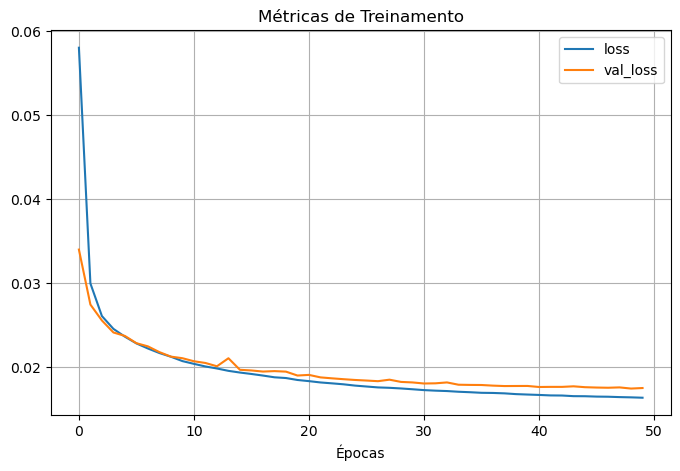

In [8]:
# Training Metrics

plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas")
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


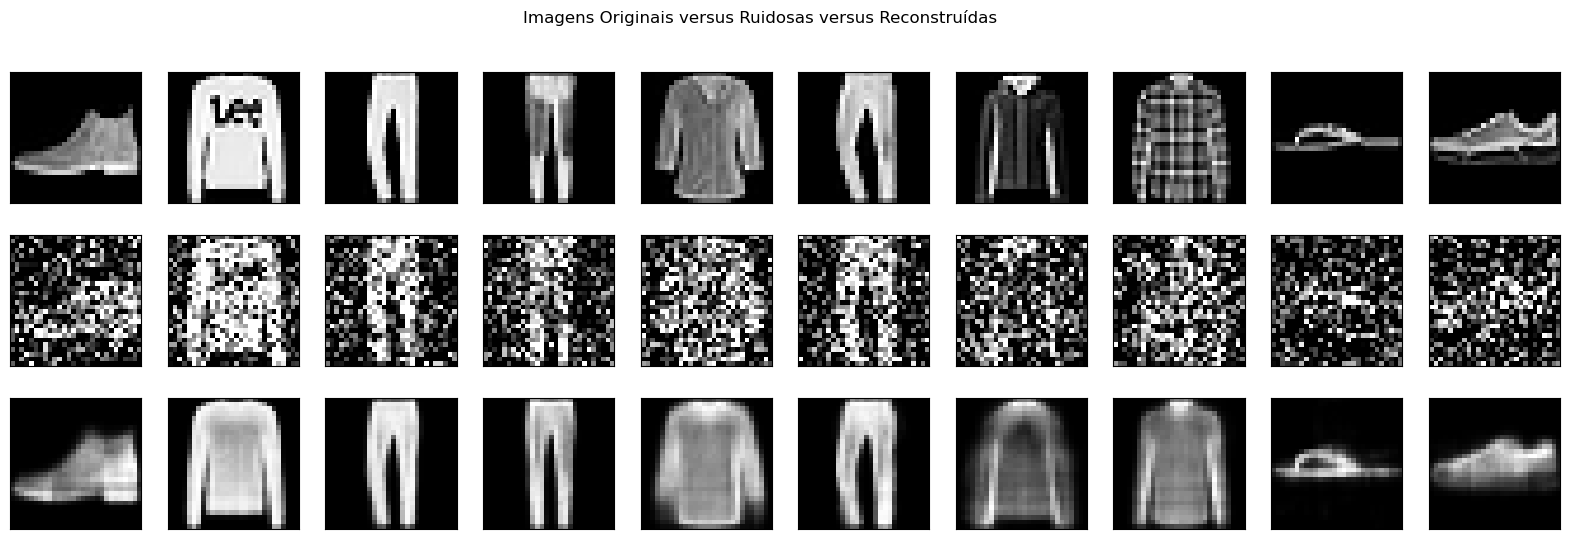

In [9]:
# Generates Reconstructions for the First 10 Images of the Test Set
reconstructed_imgs = autoencoder.predict(x_test_noisy[:10])

# View Original and Reconstructed Images
n = 10  # Number of Images to Display

plt.figure(figsize=(20, 6))
for i in range(n):
    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Noisy Image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed Image
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.suptitle("Imagens Originais versus Ruidosas versus Reconstruídas")
plt.show()